In [26]:
import glob
import pandas as pd

In [27]:
all_files = glob.glob('Sales/Sales_*.csv')

all_months_data = pd.concat([pd.read_csv(f) for f in all_files], ignore_index=True)

# We will base our analysis on the monthly sales data of a smartphone and gadget company - Solving business problems

### Question 1: Which month had the highest sales (revenue)?

In [36]:
# 1. Clean data: drop empty rows and duplicate headers
all_months_data = all_months_data.dropna(how='all')
all_months_data = all_months_data[all_months_data['Order Date'] != 'Order Date']

# 2. Convert numeric columns to proper data types
all_months_data['Quantity Ordered'] = pd.to_numeric(all_months_data['Quantity Ordered'])
all_months_data['Price Each'] = pd.to_numeric(all_months_data['Price Each'])

# 3. Calculate Sales (Quantity Ordered x Price Each)
all_months_data['Sales'] = all_months_data['Quantity Ordered'] * all_months_data['Price Each']

# 4. Convert Order Date to datetime and extract the month name
all_months_data['Order Date'] = pd.to_datetime(all_months_data['Order Date'], format='%m/%d/%y %H:%M')
all_months_data['Month'] = all_months_data['Order Date'].dt.month_name()  # <--- Changed here

# 5. Group by month name and sum the sales
monthly_sales = all_months_data.groupby('Month')['Sales'].sum().reset_index()

# 6. Find and print the month with the maximum sales
best_month = monthly_sales.loc[monthly_sales['Sales'].idxmax()]
print(f"The best month for sales is {best_month['Month']} with total sales of ${best_month['Sales']:.2f}")

The best month for sales is December with total sales of $4613443.34


### Question 2: Which city registered the maximum number of orders?

In [37]:
# 1. Clean data: drop empty rows and duplicate headers
all_months_data = all_months_data.dropna(how='all')
all_months_data = all_months_data[all_months_data['Order Date'] != 'Order Date']

# 2. Make sure Quantity Ordered is numeric
all_months_data['Quantity Ordered'] = pd.to_numeric(all_months_data['Quantity Ordered'])

# 3. Create a function to extract the city from the address string
def get_city(address):
    return address.split(',')[1].strip()

# 4. Apply the function to create a new 'City' column
all_months_data['City'] = all_months_data['Purchase Address'].apply(lambda x: get_city(str(x)))

# 5. Group by City and sum the total quantities ordered
city_orders = all_months_data.groupby('City')['Quantity Ordered'].sum().reset_index()

# 6. Find and print the city with the maximum number of orders
best_city = city_orders.loc[city_orders['Quantity Ordered'].idxmax()]
print(f"The city with the most orders is {best_city['City']} with {best_city['Quantity Ordered']} items sold.")

The city with the most orders is San Francisco with 50239 items sold.


### Question 3: What time should we display advertisements to maximize sales?

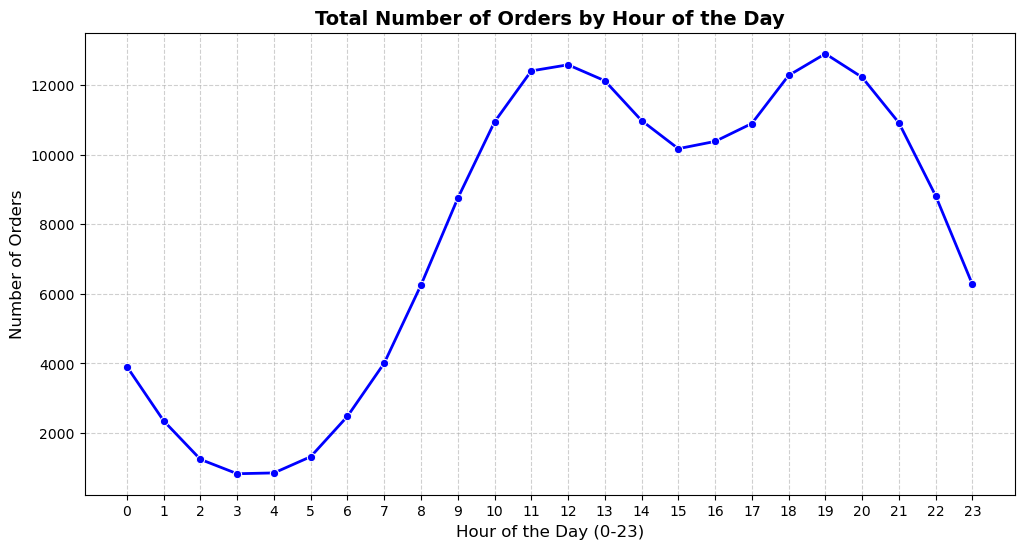

In [39]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns  

# 1. Clean data: drop empty rows and duplicate headers
all_months_data = all_months_data.dropna(how='all')
all_months_data = all_months_data[all_months_data['Order Date'] != 'Order Date']

# 2. Convert Order Date to datetime format with correct format parsing
all_months_data['Order Date'] = pd.to_datetime(all_months_data['Order Date'], format='%m/%d/%y %H:%M')

# 3. Extract the hour of the day (0-23) into a new column
all_months_data['Hour'] = all_months_data['Order Date'].dt.hour

# 4. Count the number of orders for each hour
hourly_orders = all_months_data.groupby('Hour').size().reset_index(name='Order Count')

# 5. Visualize the data using a line plot
plt.figure(figsize=(12, 6))
sns.lineplot(data=hourly_orders, x='Hour', y='Order Count', marker='o', color='b', linewidth=2)

# 6. Customize the graph labels and grid
plt.title("Total Number of Orders by Hour of the Day", fontsize=14, fontweight='bold')
plt.xlabel("Hour of the Day (0-23)", fontsize=12)
plt.ylabel("Number of Orders", fontsize=12)
plt.xticks(range(0, 24))
plt.grid(True, linestyle='--', alpha=0.6)

# Display the chart
plt.show()

### Question 4: Which product sells the most?

In [40]:
import pandas as pd

# 1. Clean data: drop empty rows and duplicate headers
all_months_data = all_months_data.dropna(how='all')
all_months_data = all_months_data[all_months_data['Order Date'] != 'Order Date']

# 2. Convert Quantity Ordered to a numeric type so we can sum it up
all_months_data['Quantity Ordered'] = pd.to_numeric(all_months_data['Quantity Ordered'])

# 3. Group by Product and sum the total quantities ordered
product_sales = all_months_data.groupby('Product')['Quantity Ordered'].sum().reset_index()

# 4. Find the product with the maximum units sold
most_sold_product = product_sales.loc[product_sales['Quantity Ordered'].idxmax()]

# 5. Print the final result
print(f"The product that sells the most is '{most_sold_product['Product']}' with a total of {most_sold_product['Quantity Ordered']:,} units sold.")

The product that sells the most is 'AAA Batteries (4-pack)' with a total of 31,017 units sold.
